# Projet de classification d'image de cellules afin de détecter le parasite de la Malaria
**Auteurs :** Capucine Schmidt, Clément Le Boulaire, Noé Vermaut

L'objectif de ce projet est de construire de A à Z un pipeline d'apprentissage automatique (Perceptron Multicouche) capable de différencier des globules rouges sains de globules parasités par la malaria.

## I. Initialisation et imports

In [52]:
import os
import sys
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image

sys.path.append(os.path.abspath(".."))

%reload_ext autoreload
%autoreload 2

import Module.Pre_traitement as pre_traitement
import Module.MLP as mlp
import Module.Evaluation as eval
import Module.Application as app 
import Module.Affichages as aff

PROJET_RACINE = os.path.abspath("..")
UNINFECTED_PATH = os.path.join(PROJET_RACINE, "Data", "Uninfected")
PARASITIZED_PATH = os.path.join(PROJET_RACINE, "Data", "Parasitized")

## II. Chargement des données et Analyse Exploratoire (EDA)
Nous chargeons les images, les redimensionnons (32x32), et extrayons un vecteur hybride contenant à la fois les pixels et 8 descripteurs.

Extraction des caractéristiques pour 1000 images par classe...
Dataset chargé : 2000 images, 1033 variables par image.



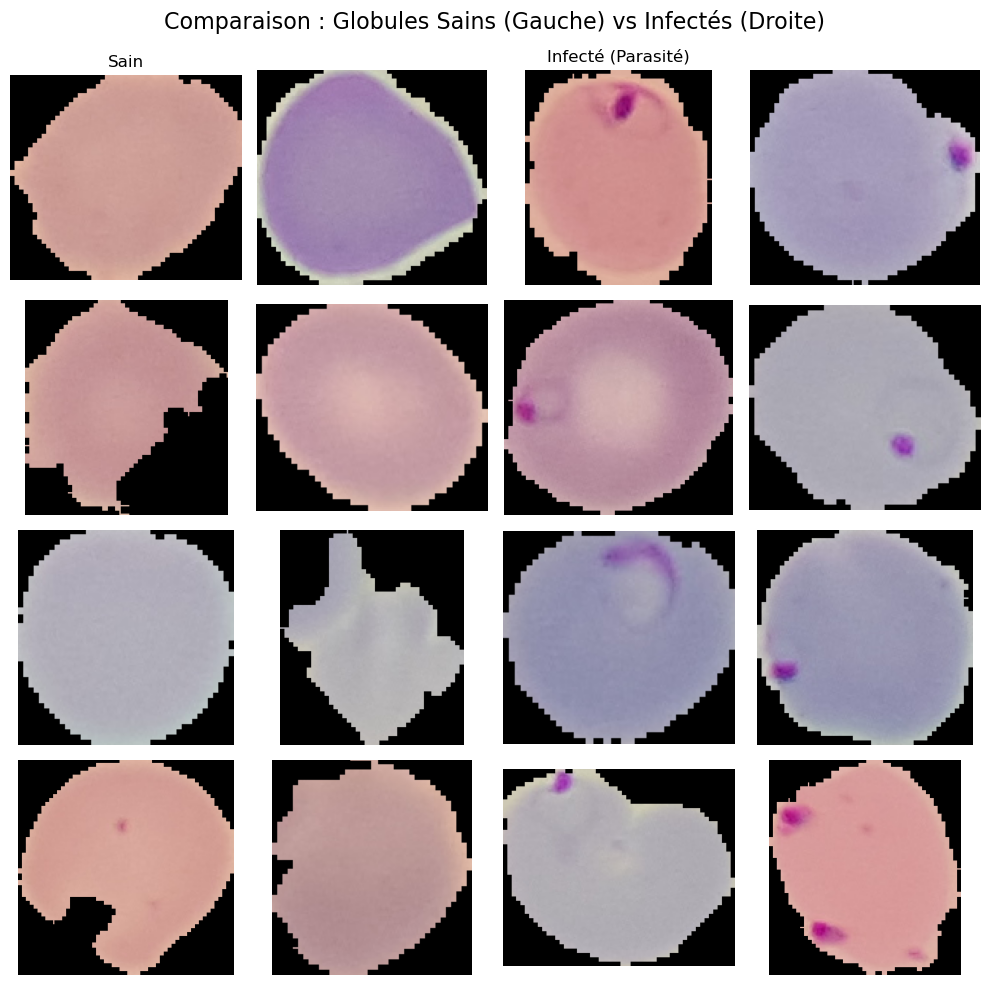

Analyse de la distribution des deux classes dans l'espace latent (PCA) :


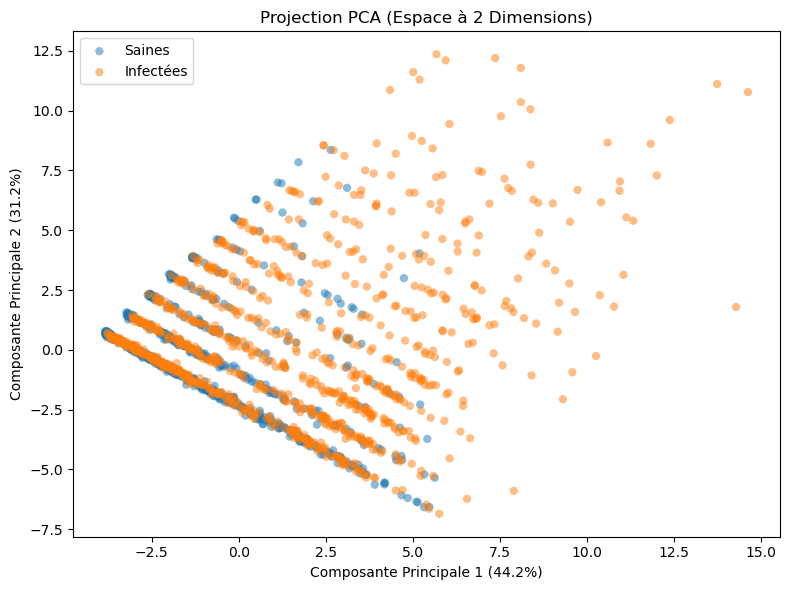

In [53]:
print(f"Extraction des caractéristiques pour {mlp.MAX_IMAGES} images par classe...")

data, target = mlp.load_images(
    uninfected_dir=UNINFECTED_PATH,
    parasitized_dir=PARASITIZED_PATH,
    image_size=mlp.TAILLE_IMAGE,
    max_per_class=mlp.MAX_IMAGES
)

print(f"Dataset chargé : {data.shape[0]} images, {data.shape[1]} variables par image.\n")

# 1. Affichage de quelques échantillons bruts
aff.plot_image_grid(UNINFECTED_PATH, PARASITIZED_PATH)

# 2. Visualisation de la séparabilité des données (PCA)
print("Analyse de la distribution des deux classes dans l'espace latent (PCA) :")
aff.plot_advanced_eda(data, target)

## III. Sélection du Modèle (Recherche d'Hyperparamètres)
Pour éviter de choisir les paramètres de notre réseau "à l'aveugle", nous lançons une recherche aléatoire (Random Search) couplée à un mécanisme d'élagage (Pruning) pour trouver rapidement la meilleure architecture.

In [54]:
print("Lancement de la recherche d'hyperparamètres...")
best_config, all_results = mlp.random_search_hyperparameters(
    data=data,
    target=target,
    train_func=mlp.mlp_fit_minibatch,
    predict_func=mlp.predict_relu,
    hidden_layer_configs=[[32, 16], [64, 32], [128, 64]],
    batch_sizes=[16, 32, 64],
    learning_rate_range=(0.001, 0.05),
    n_trials=10,
    random_state=42
)

# Sécurité en cas d'échec de la recherche
if best_config is None:
    print("Aucun modèle optimal trouvé. Utilisation de paramètres de secours.")
    best_config = {"learning_rate": 0.01, "hidden_layers": [32, 16], "batch_size": 32}

print(f"\n Configuration retenue pour l'évaluation : {best_config}")

Lancement de la recherche d'hyperparamètres...

TRIAL 1/10
hidden_layers : [32, 16]
batch_size    : 64
learning_rate : 0.005567
--- Fold 1/3 ---
Accuracy fold 1 : 0.7451 | Loss : 0.4486
--- Fold 2/3 ---
Accuracy fold 2 : 0.7196 | Loss : 0.3968
--- Fold 3/3 ---
Accuracy fold 3 : 0.7583 | Loss : 0.4111

Accuracy moyenne : 0.7410
→ accuracy = 0.7410

TRIAL 2/10
hidden_layers : [64, 32]
batch_size    : 64
learning_rate : 0.015304
--- Fold 1/3 ---
Accuracy fold 1 : 0.7766 | Loss : 0.2277
--- Fold 2/3 ---
Accuracy fold 2 : 0.7886 | Loss : 0.1938
--- Fold 3/3 ---
Accuracy fold 3 : 0.7613 | Loss : 0.2010

Accuracy moyenne : 0.7755
→ accuracy = 0.7755

TRIAL 3/10
hidden_layers : [32, 16]
batch_size    : 16
learning_rate : 0.045452
--- Fold 1/3 ---
Accuracy fold 1 : 0.8126 | Loss : 0.0560
--- Fold 2/3 ---
    -> Early Stopping à l'époque 53 (Loss opt: 0.0642)
Accuracy fold 2 : 0.7706 | Loss : 0.0777
--- Fold 3/3 ---
Accuracy fold 3 : 0.7718 | Loss : 0.0561

Accuracy moyenne : 0.7850
→ accuracy =

## IV. Évaluation (Cross-Validation K-Fold)
En utilisant les meilleurs hyperparamètres trouvés, nous évaluons la robustesse de notre modèle via une Validation Croisée à 5 plis. À l'intérieur de la boucle de validation, nous appliquons une ACP ciblée uniquement sur les pixels pour réduire le bruit tout en conservant nos descripteurs additionnels.

In [59]:
print(f"Exécution de la Validation Croisée (5 Folds)...")

cv_results = mlp.cross_validation(
    data=data, 
    target=target, 
    train_func=mlp.mlp_fit_minibatch, 
    predict_func=mlp.predict_relu, 
    n_folds=5, 
    learning_rate=best_config["learning_rate"], 
    hidden_layer_sizes=best_config["hidden_layers"], 
    batch_size=best_config["batch_size"],
    random_state=42
)

Exécution de la Validation Croisée (5 Folds)...
--- Fold 1/5 ---
    -> Early Stopping à l'époque 126 (Loss opt: 0.0155)
Accuracy fold 1 : 0.8075 | Loss : 0.0204
--- Fold 2/5 ---
    -> Early Stopping à l'époque 126 (Loss opt: 0.0125)
Accuracy fold 2 : 0.7875 | Loss : 0.0276
--- Fold 3/5 ---
    -> Early Stopping à l'époque 91 (Loss opt: 0.0229)
Accuracy fold 3 : 0.8225 | Loss : 0.0267
--- Fold 4/5 ---
Accuracy fold 4 : 0.8100 | Loss : 0.0135
--- Fold 5/5 ---
    -> Early Stopping à l'époque 139 (Loss opt: 0.0108)
Accuracy fold 5 : 0.7775 | Loss : 0.0186

Accuracy moyenne : 0.8010


### 4.1. Analyse des Métriques
Dans un contexte de diagnostic médical, notre métrique de priorité est le Rappel (Recall) : il est vital de minimiser les Faux Négatifs (patients malades renvoyés chez eux).

=== RAPPORT CLINIQUE FINAL ===
Exactitude (Accuracy) : 0.8010
Précision             : 0.8122
Rappel (Recall)       : 0.7830
Score F1              : 0.7974
Affichage de la Matrice de confusion normalisée...


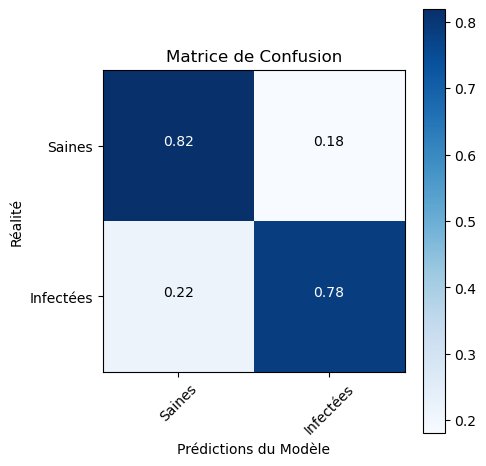

In [60]:
# Extraction de la matrice globale depuis le dictionnaire retourné par la CV
mc_globale = cv_results["confusion_matrix"]

acc = eval.exactitude(mc_globale)
prec = eval.precision(mc_globale)
rap = eval.rappel(mc_globale)
f1 = eval.score_f1(prec, rap)

print("=== RAPPORT CLINIQUE FINAL ===")
print(f"Exactitude (Accuracy) : {acc:.4f}")
print(f"Précision             : {prec:.4f}")
print(f"Rappel (Recall)       : {rap:.4f}")
print(f"Score F1              : {f1:.4f}")

# Formatage pour le graphique
cm_array = np.array([[mc_globale['VN'], mc_globale['FP']], 
                     [mc_globale['FN'], mc_globale['VP']]])

plt.figure(figsize=(5, 5))
eval.plot_confusion_matrix(cm_array, classes=['Saines', 'Infectées'], normalize=True)
plt.show()

## V. Entraînement et Sauvegarde
Le comportement de notre réseau étant validé, nous l'entraînons une dernière fois sur 100 % des données disponibles pour capturer un maximum d'information avant de l'exporter.

Préparation du modèle de production...
    -> Early Stopping à l'époque 105 (Loss opt: 0.1197)


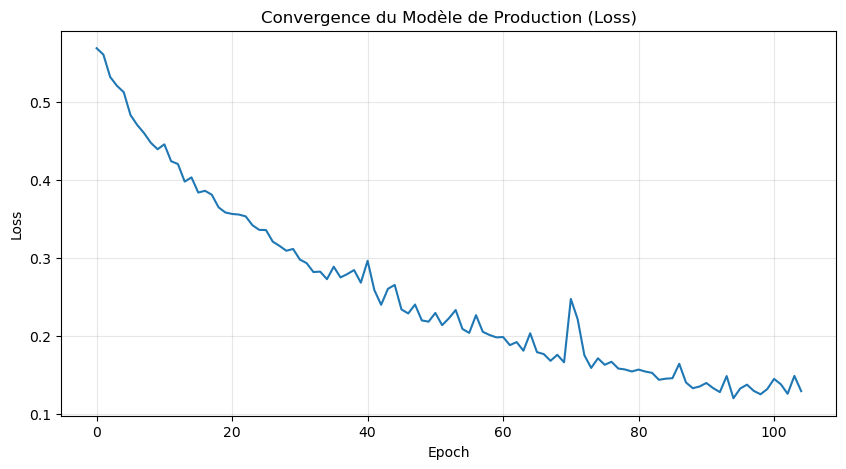

Modèle 'modele_malaria.npz' sauvegardé avec succès et prêt au déploiement.


In [61]:
print("Préparation du modèle de production...")

# 1. Normalisation globale stricte
mean_final = np.mean(data, axis=0)
std_final = np.std(data, axis=0)
std_final = np.where(std_final < 1e-8, 1e-8, std_final)
data_scaled = np.clip((data - mean_final) / std_final, -5, 5)

# 2. Séparation Pixels / Experts
n_pixels = mlp.TAILLE_IMAGE[0] * mlp.TAILLE_IMAGE[1]
data_pixels = data_scaled[:, :n_pixels]
data_experts = data_scaled[:, n_pixels:]

# 3. Réduction de dimension (PCA) réservée aux pixels
pca_final = mlp.PCA(n_components=mlp.COMPOSANTES_PCA, random_state=42)
data_pixels_pca = pca_final.fit_transform(data_pixels)

# 4. Fusion du vecteur d'entrée final
data_production = np.concatenate([data_pixels_pca, data_experts], axis=1)

# 5. Entraînement Final
w_final, b_final, losses = mlp.mlp_fit_minibatch(
    data_production, target, 
    n_epochs=mlp.EPOCHS, 
    hidden_layer_sizes=best_config["hidden_layers"],
    learning_rate=best_config["learning_rate"], 
    batch_size=best_config["batch_size"], 
    random_state=42, 
    dropout_rate=mlp.TAUX_DROPOUT, 
    patience=mlp.PATIENCE, 
    lambda_reg=mlp.LAMBDA_L2
)

# Visualisation de la convergence (Loss)
aff.plot_losses(losses, title="Convergence du Modèle de Production (Loss)")

# 6. Sauvegarde du modèle final
mlp.save_model("modele_malaria.npz", w_final, b_final, mean_final, std_final, pca_final.components_, pca_final.mean_)
print("Modèle 'modele_malaria.npz' sauvegardé avec succès et prêt au déploiement.")

## VI. Démonstration de l'Application (Inférence)
Mise en situation : on soumet une image totalement inconnue à notre algorithme sauvegardé pour obtenir un diagnostic automatique.

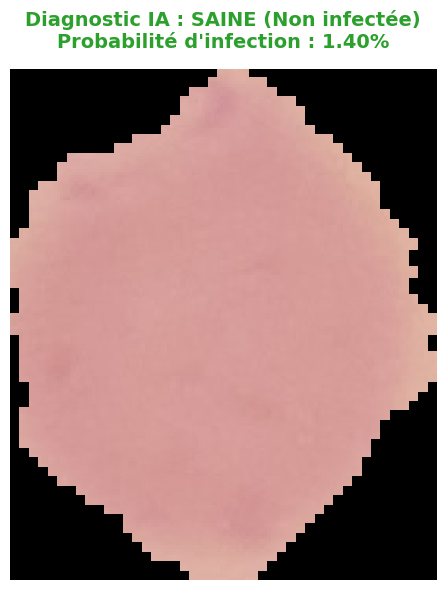

In [62]:
# Chargement du poids des neurones et des paramètres de prétraitement
w_l, b_l, m_l, s_l, p_comp, p_mean = mlp.load_model("modele_malaria.npz")

# Simulation : Sélection d'une image pour la démo
test_image_path = os.path.join(PARASITIZED_PATH, os.listdir(PARASITIZED_PATH)[0])

# Exécution du diagnostic avec interface utilisateur
app.diagnostiquer_une_cellule(
    test_image_path, w_l, b_l, m_l, s_l, p_comp, p_mean, 
    image_size=mlp.TAILLE_IMAGE, seuil=mlp.SEUIL_DECISION
)